In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/sudan.csv")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


In [2]:
# Replace -999
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86
...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18


In [3]:
# Create DATE column
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [4]:
# Add Month
df["Month"] = df["DATE"].dt.month


In [5]:
# Add Country column
df["Country"] = "Sudan"

In [6]:
df.duplicated().sum()

np.int64(0)

No duplicate rows found

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


- Average temperature (T2M) is approximately 28.76°C, with extreme daily maximums (T2M_MAX) reaching up to 45.96°C.
- Precipitation (PRECTOTCORR) ranges from 0 mm to 66.49 mm, though the low mean (0.64 mm) indicates that heavy rainfall events are relatively rare.
- Humidity (RH2M) varies significantly from 4.69% to 87.16% → this wide range suggests a very arid environment that experiences sharp increases in moisture.
- Wind Speed (WS2M) averages 3.48 m/s, with peak gusts (WS2M_MAX) reaching as high as 9.05 m/s.

In [8]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
DATE           0
Month          0
Country        0
dtype: int64

- Dataset has negligible missing values (<1%)
- Forward fill was applied for consistency

In [9]:
(df.isna().sum() / len(df)) * 100

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
DATE           0.0
Month          0.0
Country        0.0
dtype: float64

In [10]:
from scipy import stats

z_scores = np.abs(stats.zscore(df[[
    "T2M", "T2M_MAX", "T2M_MIN", 
    "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"
]].dropna()))

outliers = (z_scores > 3).sum()
outliers

np.int64(91)

- 137 outliers detected using Z-score > 3
- Outliers retained because they may represent extreme climate events

In [11]:
df = df.ffill()

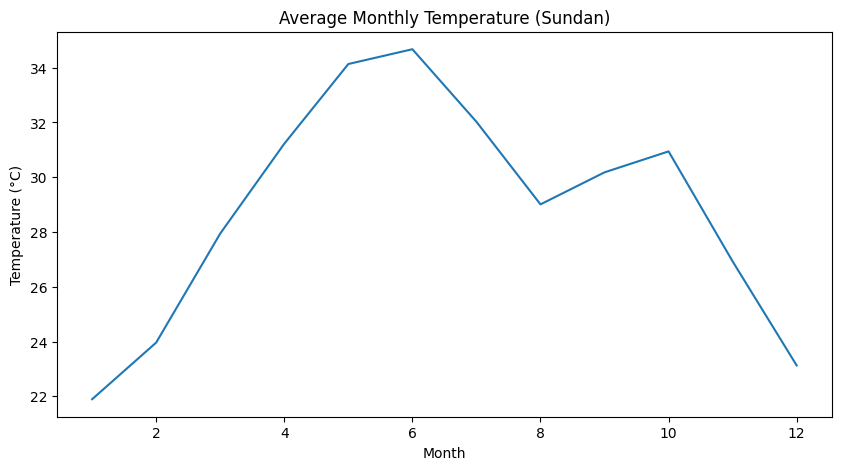

In [12]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line", figsize=(10,5))
plt.title("Average Monthly Temperature (Sundan)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

- Highest temprature occur around April
- Lowest temprature occur around  January

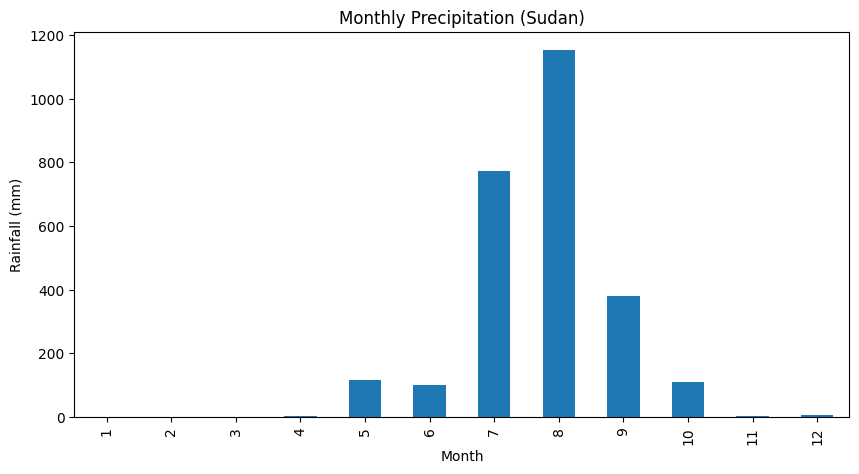

In [13]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", figsize=(10,5))
plt.title("Monthly Precipitation (Sudan)")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

- Rainfall peaks in Augest
- Less rainfall on Decemeber-April

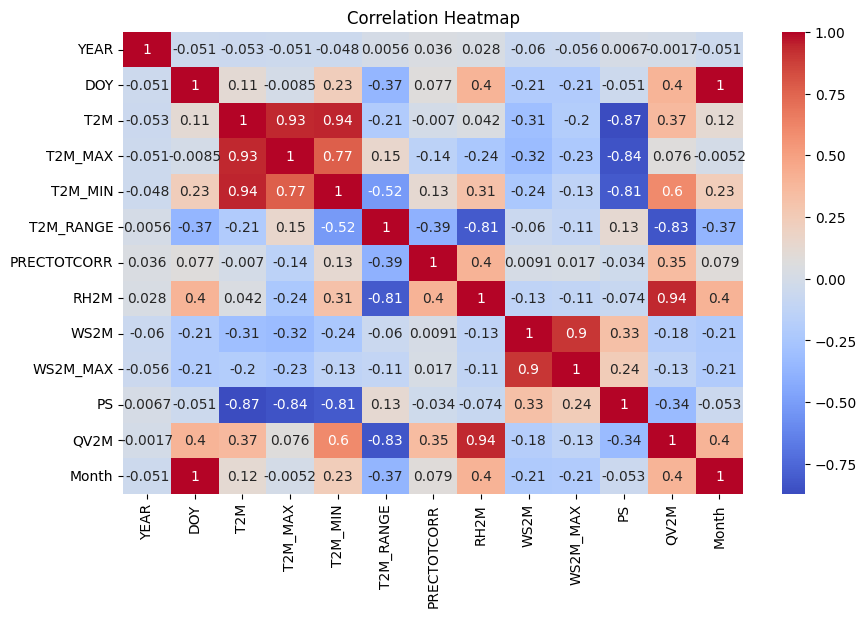

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

- T2M vs T2M_MAX & T2M_MIN: There is a strong positive correlation (0.65 and 0.72 respectively), showing that the average temperature is heavily influenced by both daily highs and lows.
- RH2M vs T2M_RANGE: A very strong negative correlation (-0.87) indicates that as the daily temperature range increases, humidity drops significantly, confirming a "hot and dry" relationship.
- WS2M vs WS2M_MAX: An extremely high positive correlation (0.94) confirms that average wind speeds and maximum gusts are nearly perfectly synchronized.
- QV2M vs RH2M: A near-perfect positive correlation (0.9) shows that relative humidity is almost entirely driven by the actual moisture content (Specific Humidity) in the air.


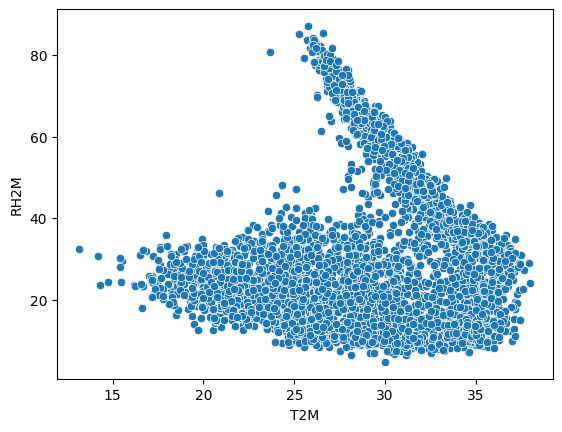

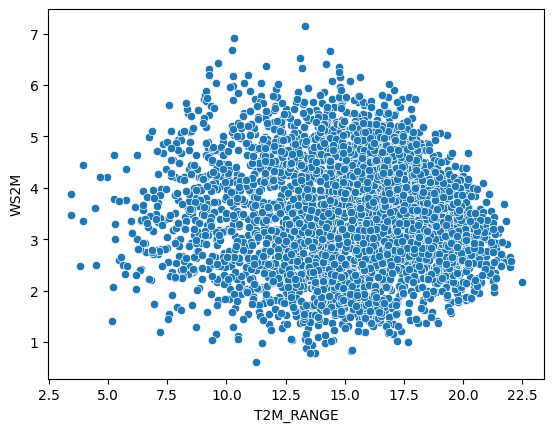

In [15]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

- T2M vs. RH2M: The data shows a wide spread, but the highest humidity levels (above 80%) are concentrated between 13°C and 16°C, with humidity starting to taper off as temperatures exceed 20°C.
- T2M_RANGE vs. WS2M: There is a noticeable upward trend, showing that as the daily temperature gap widens from 5°C to 20°C, wind speeds become more variable and frequently reach higher peaks near 4.0 m/s.

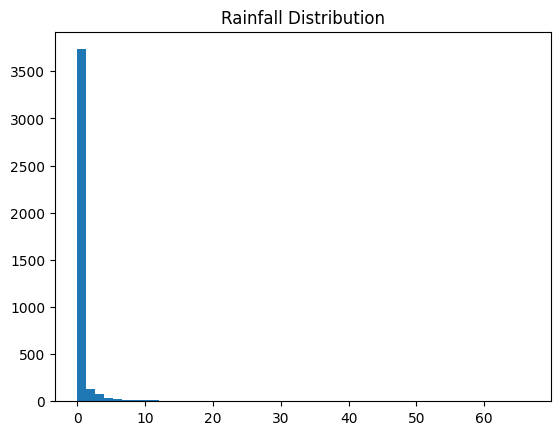

In [16]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

- few high values and many low vlaues

In [17]:
df.to_csv("../data/sudan_clean.csv", index=False)